# Разные способы реализации весов (взвешивание) в kNN.

## 0. Подготовка.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_regression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Данные для классификации.

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

sc = StandardScaler().fit(X_train)
X_train, X_test = sc.transform(X_train), sc.transform(X_test)

# Сетка для рисования решающей границы
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-0.5, X_train[:,0].max()+0.5, 300),
                     np.linspace(X_train[:,1].min()-0.5, X_train[:,1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

def plot_boundary(model, X, y, ax, title):
    model.fit(X, y)
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap='coolwarm', s=25)
    ax.set_title(title)

## 2. Стандартные веса sklearn: `uniform` vs `distance`.

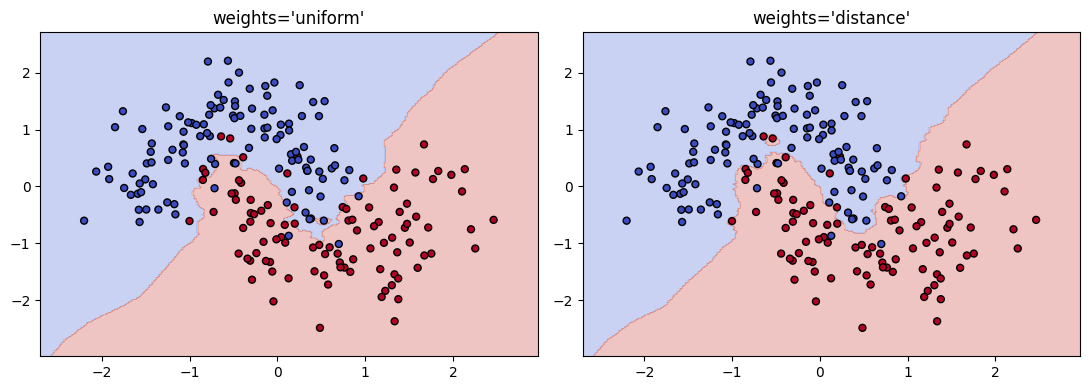

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, w in zip(axes, ['uniform', 'distance']):
    plot_boundary(KNeighborsClassifier(n_neighbors=10, weights=w), X_train, y_train, ax, f"weights='{w}'")

plt.tight_layout()
plt.show()

`uniform` - это $w_{i} = 1$, для любого i. Работает "из коробки". Все соседи голосуют одинаково. Это базовый kNN. В sklearn `weights = 'uniform'` возвращает None на уровне `_get_weights` - это значит "веса не используются, голосование обычное".

`distance` - это $w_{i} = \frac{1}{d_{i}}$, где $d_{i}$ - расстояние до i-го соседа. Работает "из коробки", но упирается в деление на ноль при совпадении точек. Ближние соседи влияют сильнее. Если тестовая точка совпадает с обучающей (расстояние 0), sklearn присваивает этой точке вес 1.0, а остальным 0.0, чтобы избежать деления на ноль.

## 3. Ранговые веса (не зависят от расстояния).

`weights` в sklearn может быть callable: функция получает массив расстояний и возвращает массив весов.

In [4]:
def rank_linear(dist):
    # w_i = (k + 1 - i) / k
    # i - ранг соседа (1..k), т.е. позиция в списке, отсортированном по расстоянию до запроса.
    # i = 1 - самый близкий сосед, i = k - самый дальний.
    # dist: (n_queries, n_neighbors)
    k = dist.shape[1]    # число соседей
    ranks = np.arange(1, k + 1, dtype=np.float64)  # [1, 2, ..., k]
    w = (k + 1 - ranks) / k
    return np.broadcast_to(w, dist.shape).copy()  # [(k)/k, (k - 1)/k, ..., 1/k]

def rank_exp(q = 0.5):
    # w_i = q^i
    # i - ранг соседа (1..k), i = 1 - самый близкий, i = k - самый дальний.
    # q ∈ (0, 1): чем меньше q, тем сильнее фокус на ближайшем соседе.
    # при k = 5, q = 0.5: w = [0.5, 0.25, 0.125, 0.0625, 0.03125].
    def f(dist):
        k = dist.shape[1]
        ranks = np.arange(1, k + 1, dtype=np.float64)
        w = q ** ranks
        return np.broadcast_to(w, dist.shape).copy()
    return f

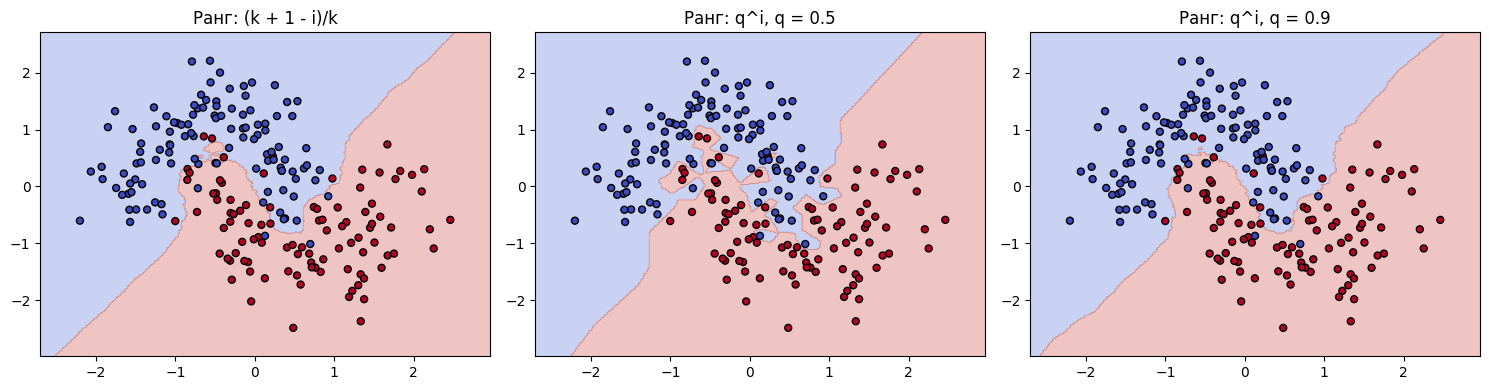

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_boundary(KNeighborsClassifier(10, weights=rank_linear),   X_train, y_train, axes[0], "Ранг: (k + 1 - i)/k")
plot_boundary(KNeighborsClassifier(10, weights=rank_exp(0.5)), X_train, y_train, axes[1], "Ранг: q^i, q = 0.5")
plot_boundary(KNeighborsClassifier(10, weights=rank_exp(0.9)), X_train, y_train, axes[2], "Ранг: q^i, q = 0.9")

plt.tight_layout()
plt.show()

Эти веса зависят только от порядка соседей, а не от реальных расстояний. Поэтому границы почти не меняются при смене `q` в разумном диапазоне. Только при экстремальных `q` (например, `q = 0.01` - почти 1-NN или `q = 0.99` - почти `uniform`) картинка заметно меняется. Конкретные "экстремальные" значения зависят от `k`.

## 4. Ядровые веса (парзеновское окно).

`weights` через кастомное ядро с шириной окна.

In [6]:
def kernel_weights(kernel, h):
    # Парзеновское окно: w_i = K(rho(x, x_i) / h)
    # kernel - функция ядра K (например, gaussian, epanechnikov, ...)
    # h - ширина окна (bandwidth): управляет сглаживанием:
    #     h маленькое - учитываются только очень близкие соседи (переобучение).
    #     h большое   - веса почти одинаковые (недообучение).
    # Возвращаем функцию от dist, как ожидает sklearn в weights = ...
    def f(dist):
        z = dist / h  # масштабирование расстояния на ширину окна.
        return kernel(z)  # применяем ядро поэлементно.
    return f

eps_underflow = 1e-12  # защита ядер от underflow
# Ядра
gaussian = lambda z: np.maximum(np.exp(-0.5 * z**2), eps_underflow)
epanechnikov = lambda z: np.where(np.abs(z) <= 1, 0.75 * (1 - z**2), eps_underflow)
quartic    = lambda z: np.where(np.abs(z) <= 1, 15/16 * (1 - z**2)**2, eps_underflow)
triangular = lambda z: np.where(np.abs(z) <= 1, 1 - np.abs(z), eps_underflow)

Гиперпараметр `h` - не менее важный, чем `n_neighbors`: он управляет bias-variance (смещение / дисперсия) tradeoff так же сильно, как `k` в базовом kNN.

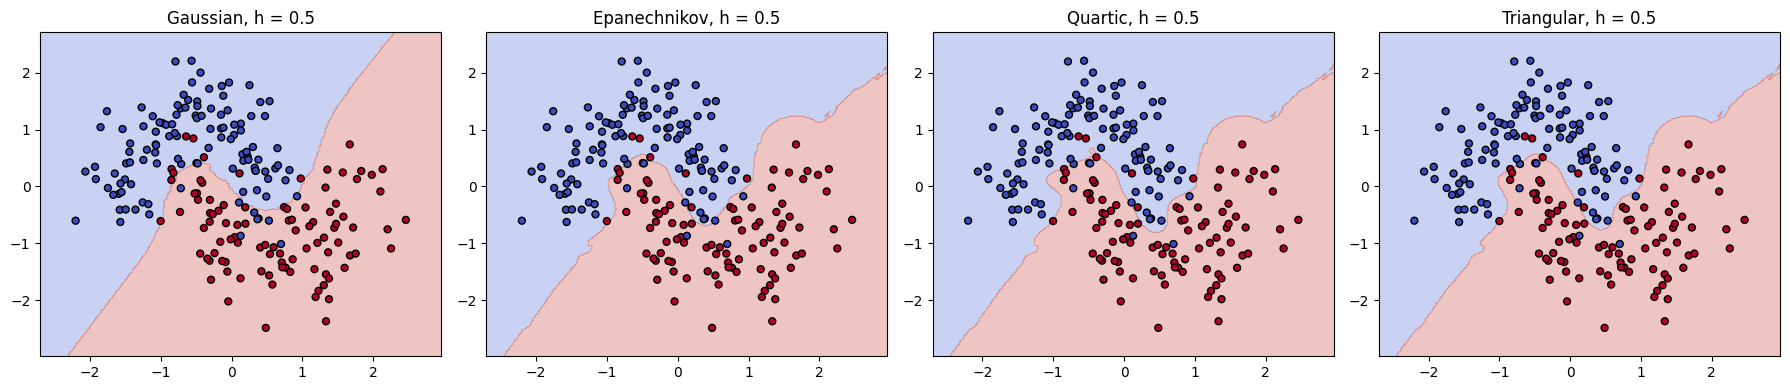

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

plot_boundary(KNeighborsClassifier(30, weights=kernel_weights(gaussian, 0.5)),     X_train, y_train, axes[0], "Gaussian, h = 0.5")
plot_boundary(KNeighborsClassifier(30, weights=kernel_weights(epanechnikov, 0.5)), X_train, y_train, axes[1], "Epanechnikov, h = 0.5")
plot_boundary(KNeighborsClassifier(30, weights=kernel_weights(quartic, 0.5)),      X_train, y_train, axes[2], "Quartic, h = 0.5")
plot_boundary(KNeighborsClassifier(30, weights=kernel_weights(triangular, 0.5)),   X_train, y_train, axes[3], "Triangular, h = 0.5")

plt.tight_layout()
plt.show()

Все четыре ядра дают похожие решающие границы - форма ядра влияет слабее, чем ширина окна `h`, потому что `h` напрямую управляет bias-variance tradeoff.

Единственное принципиальное различие: гауссово ядро устойчиво (никогда не обнуляет веса), а финитные ядра могут "слепнуть" вдали от данных и требуют `ε` (epsilon) или аккуратного выбора `h`.

## 5. Роль ширины окна `h` - bias-variance tradeoff.

Одно ядро (гауссово), три разных `h`:

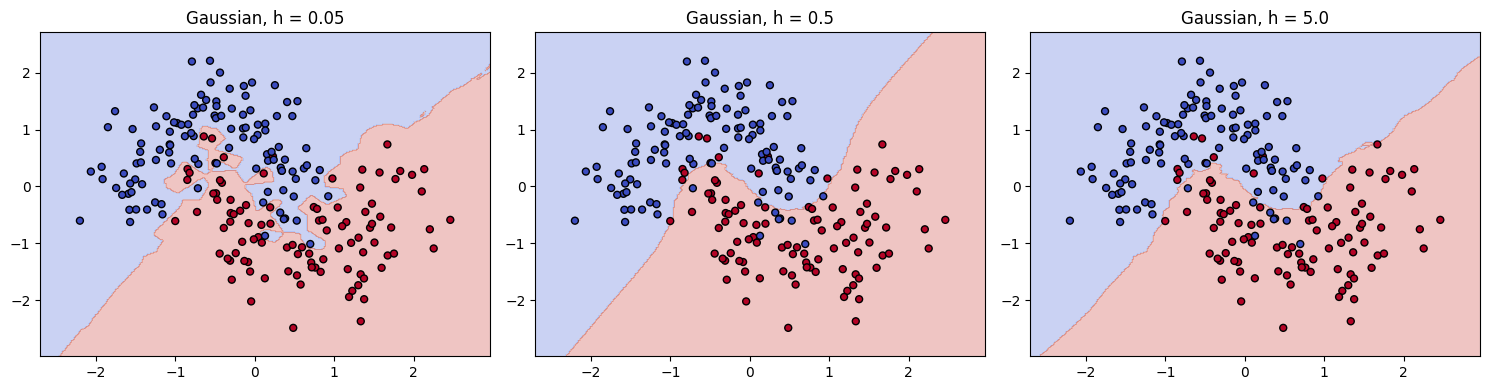

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h in zip(axes, [0.05, 0.5, 5.0]):
    plot_boundary(KNeighborsClassifier(30, weights=kernel_weights(gaussian, h)),
                  X_train, y_train, ax, f"Gaussian, h = {h}")

plt.tight_layout()
plt.show()

Разные варианты:

* `h = 0.05` - узкое окно: граница изрезанная, переобучение.
* `h = 5` - широкое окно: веса почти одинаковые - вырождается в обычный (`uniform`) kNN.
* `h = 0.5` - компромисс.

Ширина окна `h` - главный регулятор bias-variance tradeoff: при малом `h` граница изрезанная (переобучение), при большом - сглаженная вплоть до вырождения в обычный (`uniform`) kNN, а `h = 0.5` даёт компромисс. Форма ядра при этом влияет куда слабее, чем `h`.

## 6. Обратное расстояние со сглаживанием (свой "distance + epsilon (ε)").

Показывает, как бороться с делением на ноль:

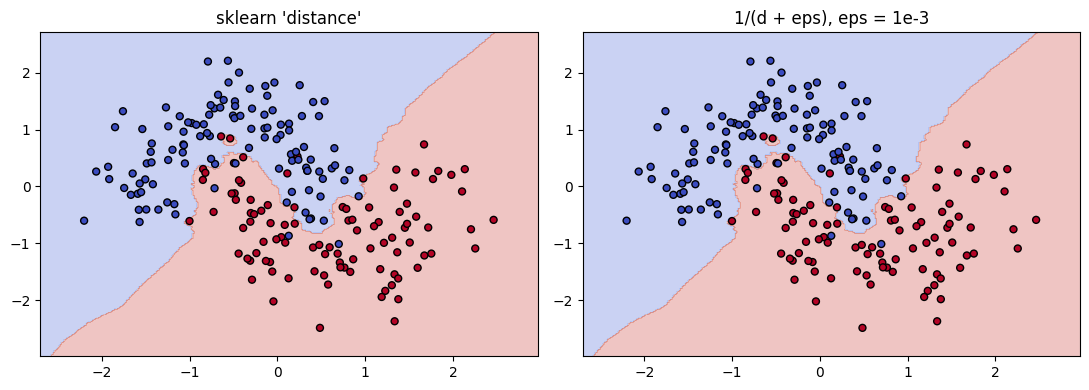

In [9]:
eps_dist = 1e-3

def inv_dist_eps(eps):
    return lambda dist: 1.0 / (dist + eps)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_boundary(KNeighborsClassifier(10, weights='distance'),         X_train, y_train, axes[0], "sklearn 'distance'")
plot_boundary(KNeighborsClassifier(10, weights=inv_dist_eps(eps_dist)), X_train, y_train, axes[1], "1/(d + eps), eps = 1e-3")

plt.tight_layout()
plt.show()

`weights = 'distance'` из sklearn и своя формула `1/(d + ε)` дают практически одинаковые границы - сглаживание `ε` не меняет картину, но защищает от деления на ноль при совпадении точек. Это показывает, что `ε` - не "подмена метода", а чисто техническая страховка: метод остаётся тем же.

`ε` не меняет метод - он лишь делает формулу $\frac{1}{d}$ численно безопасной при `d = 0`, поэтому границы почти совпадают с sklearn 'distance'.

## 7. Формула Надарая-Ватсона (регрессия).

Отличие от `kNN`: суммируем по всем точкам формально (вклад далёких ядро делает пренебрежимо малым), а не отбираем ровно `k` ближайших.

Надарая-Ватсон - это метод ядровой регрессии: оценка в точке - это взвешенное среднее всех $y_{i}$​, где вес точки задаётся ядром от её расстояния до запроса. Это отдельный метод: он не отбирает `k` соседей жёстко, а взвешивает точки по расстоянию, где локальность задаётся шириной окна `h` (а не числом соседей `k`).

In [10]:
def nadaraya_watson(X_train, y_train, X_query, h=0.3, kernel=gaussian):
    # Ядровая регрессия Надарая-Ватсона:
    # y_hat(x) = sum_i K(d(x, x_i)/h) * y_i / sum_i K(d(x, x_i)/h)
    # Отличие от kNN: формально суммируем по всем n точкам, а не по k ближайшим.
    # X_train: (n, d) - обучающие точки.
    # y_train: (n,) - их ответы.
    # X_query: (m, d) - точки, где хотим предсказать.
    # h - ширина окна (bandwidth), аналог k в kNN.
    # kernel - функция ядра K.

    # d2[i, j] = квадрат расстояния между X_query[i] и X_train[j]
    # Broadcasting: X_query[:, None, :] имеет форму (m, 1, d),
    #               X_train[None, :, :] имеет форму (1, n, d),
    #               разность - (m, n, d), сумма по последней оси - (m, n).
    d2 = ((X_query[:, None, :] - X_train[None, :, :])**2).sum(-1)
    d = np.sqrt(d2)  # (m, n) - матрица расстояний.

    W = kernel(d / h)  # (m, n) - матрица весов (ядро от нормированных расстояний).

    # Взвешенное среднее: сумма(w * y) / сумма(w) по всем n точкам.
    return (W * y_train).sum(1) / W.sum(1)

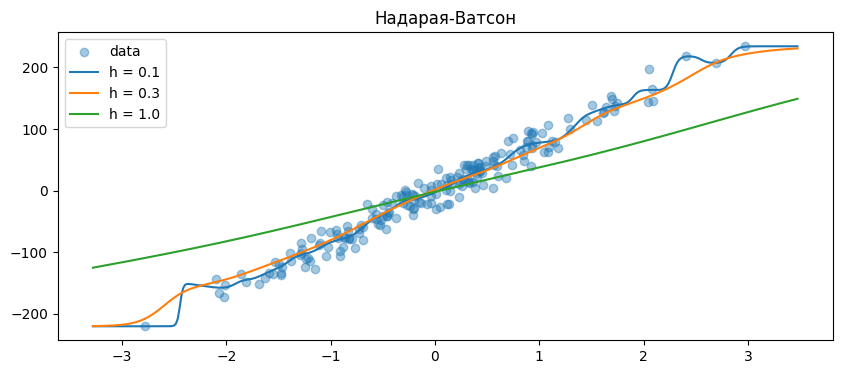

In [11]:
# 1D-регрессия для наглядности

Xr, yr = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
Xr = StandardScaler().fit_transform(Xr)

xs = np.linspace(Xr.min()-0.5, Xr.max()+0.5, 400).reshape(-1, 1)
plt.scatter(Xr, yr, alpha=0.4, label='data')

for h in [0.1, 0.3, 1.0]:
    plt.plot(xs, nadaraya_watson(Xr, yr, xs, h = h), label=f'h = {h}')

plt.legend()
plt.title("Надарая-Ватсон")
plt.show()

Сравнение с `KNeighborsRegressor`:

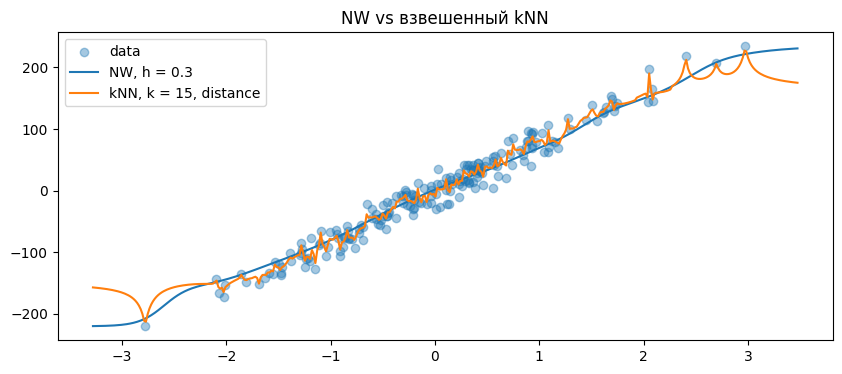

In [12]:
plt.scatter(Xr, yr, alpha = 0.4, label = 'data')
plt.plot(xs, nadaraya_watson(Xr, yr, xs, h = 0.3), label = 'NW, h = 0.3')

kr = KNeighborsRegressor(15, weights = 'distance').fit(Xr, yr)
plt.plot(xs, kr.predict(xs), label = 'kNN, k = 15, distance')

plt.legend()
plt.title("NW vs взвешенный kNN")
plt.show()

На краях `xs` (за пределами `Xr`) у `NW` вес получают все точки, и оценка плавно "сдувается" к среднему. У `kNN` же всегда ровно 15 соседей, и на краю они все оказываются с одной стороны - отсюда "излом" или "ступенька". Это фундаментальное различие: `NW` устойчив к границам, `kNN` - нет.

## 8. Сравнение точности на кросс-валидации (бонус).

А что лучше на цифрах?

In [13]:
weights_list = {
    'uniform':       'uniform',
    'distance':      'distance',
    'rank_linear':   rank_linear,
    'rank q=0.5':    rank_exp(0.5),
    'gauss h=0.3':   kernel_weights(gaussian, 0.3),
    'gauss h=1.0':   kernel_weights(gaussian, 1.0),
    'epan h=0.5':    kernel_weights(epanechnikov, 0.5),
}

for name, w in weights_list.items():
    clf = KNeighborsClassifier(n_neighbors = 15, weights=w)
    scores = cross_val_score(clf, X_train, y_train, cv = 5, scoring = 'accuracy')
    print(f"{name:15s} acc = {scores.mean():.3f} ± {scores.std():.3f}")

uniform         acc = 0.895 ± 0.039
distance        acc = 0.910 ± 0.028
rank_linear     acc = 0.900 ± 0.038
rank q=0.5      acc = 0.910 ± 0.028
gauss h=0.3     acc = 0.905 ± 0.040
gauss h=1.0     acc = 0.895 ± 0.039
epan h=0.5      acc = 0.900 ± 0.028


Все методы дают точность в диапазоне `0.895-0.910`, различия - в пределах стандартного отклонения кросс-валидации. Это значит, что на данных `make_moons` форма веса почти не влияет на качество - важнее сам факт взвешивания (против `uniform`). Исключение - `gauss h=1.0`, который буквально совпал с `uniform`, подтверждая теорию: при большом `h` веса вырождаются в равные.

## Выводы.

1. weights в sklearn - либо строка ('uniform', 'distance'), либо callable от массива расстояний.
2. Ранговые веса - игнорируют геометрию, зависят только от порядка.
3. Ядровые веса - парзеновское окно, ключевой параметр - h (bias-variance).
4. Надарая–Ватсон - ядровая регрессия с шириной окна h вместо числа соседей k.
5. Всё это - разные способы ответить на один вопрос: "насколько сильно доверять каждому соседу?"